# ⚡ LightGBM Quantile Regression — Load Forecasting

This notebook trains a **LightGBM Quantile Regression** model on the integrated load dataset to produce:
- **P10** (10th percentile — lower bound)
- **P50** (50th percentile — median forecast)
- **P90** (90th percentile — upper bound)

---

## 1. Install & Import Libraries

In [1]:
# Install required packages (run once)
!pip install lightgbm scikit-learn pandas numpy matplotlib seaborn --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
import os
import pickle

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

print(f"LightGBM version: {lgb.__version__}")
print(f"Working directory: {os.getcwd()}")

LightGBM version: 4.6.0
Working directory: D:\ARFA PROJECTS\Decodex Dalmia\Dalmia Round 1\model training


---
## 2. Load & Explore Data

In [3]:
# Load the integrated dataset
DATA_PATH = 'Integrated_Load_Data_Final.csv'
df = pd.read_csv(DATA_PATH)

print(f"Dataset Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head(10)

Dataset Shape: (283391, 9)
Columns: ['DATETIME', 'ACT_HEAT_INDEX', 'ACT_HUMIDITY', 'ACT_RAIN', 'ACT_TEMP', 'COOL_FACTOR', 'Event_Name', 'Holiday_Ind', 'LOAD']


,DATETIME,ACT_HEAT_INDEX,ACT_HUMIDITY,ACT_RAIN,ACT_TEMP,COOL_FACTOR,Event_Name,Holiday_Ind,LOAD
0,01-04-2013 00:15,26.289972,67.65,0.0,25.88,0.0,Normal Day,0,1136.0
1,01-04-2013 00:30,26.145567,68.86,0.0,25.72,0.0,Normal Day,0,1111.0
2,01-04-2013 00:45,26.048589,69.78,0.0,25.61,0.0,Normal Day,0,1081.0
3,01-04-2013 01:00,25.938489,71.04,0.0,25.48,0.0,Normal Day,0,1050.0
4,01-04-2013 01:15,25.891289,71.76,0.0,25.42,0.0,Normal Day,0,1023.0
5,01-04-2013 01:30,25.729911,72.32,0.0,25.26,0.0,Normal Day,0,995.0
6,01-04-2013 01:45,25.596572,72.69,0.0,25.13,0.0,Normal Day,0,964.0
7,01-04-2013 02:00,25.499072,73.59,0.0,25.02,0.0,Normal Day,0,948.0
8,01-04-2013 02:15,25.362306,74.25,0.0,24.88,0.0,Normal Day,0,935.0
9,01-04-2013 02:30,25.167144,74.78,0.0,24.69,0.0,Normal Day,0,919.0


In [4]:
# Basic statistics
df.describe()

,ACT_HEAT_INDEX,ACT_HUMIDITY,ACT_RAIN,ACT_TEMP,COOL_FACTOR,Holiday_Ind,LOAD
count,283391.000000,283391.000000,283391.000000,283391.000000,283391.000000,283391.000000,283391.000000
mean,31.385513,72.944769,0.073576,27.985748,1.820891,0.111112,1225.646874
std,6.069194,16.117998,0.678295,3.258865,2.274297,0.314271,257.617659
min,16.102656,10.000000,0.000000,16.150000,0.000000,0.000000,331.000000
25%,26.718058,62.280000,0.000000,25.950000,0.000000,0.000000,1034.000000
50%,30.973312,74.670000,0.000000,27.810000,0.810000,0.000000,1229.000000
75%,35.260982,84.830000,0.000000,30.100000,3.100000,0.000000,1426.000000
max,55.677276,100.000000,43.250000,41.170000,14.170000,1.000000,1964.000000


In [5]:
# Check for null values
print("Null Values:")
print(df.isnull().sum())
print(f"\nTotal rows: {len(df):,}")
print(f"Date range: {df['DATETIME'].min()} to {df['DATETIME'].max()}")

Null Values:
DATETIME          0
ACT_HEAT_INDEX    0
ACT_HUMIDITY      0
ACT_RAIN          0
ACT_TEMP          0
COOL_FACTOR       0
Event_Name        0
Holiday_Ind       0
LOAD              0
dtype: int64

Total rows: 283,391
Date range: 01-01-2014 00:00 to 31-12-2020 23:45


In [6]:
# Unique events
print("Unique Event Names:")
print(df['Event_Name'].value_counts())

Unique Event Names:
Event_Name
Normal Day                        227903
Unlock 2.0/Mission Begin Again      2880
Unlock 1.0/Mission Begin Again      2784
Unlock 4.0                          2784
Unlock 5.0                          1824
                                   ...  
Extremely Heavy Rain                  96
Cyclone Nisarga                       96
Grid Failure                          96
Cinema Halls - 50                     96
Cinema Halls - 100                    96
Name: count, Length: 73, dtype: int64


---
## 3. Feature Engineering

In [7]:
# Parse DATETIME
# The format is DD-MM-YYYY HH:MM (e.g., 01-04-2013 00:15)
df['DATETIME'] = pd.to_datetime(df['DATETIME'], format='%d-%m-%Y %H:%M', errors='coerce')

# If the above format didn't work, try dayfirst=True
if df['DATETIME'].isnull().sum() > 0:
    df['DATETIME'] = pd.to_datetime(df['DATETIME'], dayfirst=True, errors='coerce')

print(f"Date range: {df['DATETIME'].min()} to {df['DATETIME'].max()}")
print(f"Null datetimes: {df['DATETIME'].isnull().sum()}")

# Drop rows with null datetimes
df = df.dropna(subset=['DATETIME'])
df = df.sort_values('DATETIME').reset_index(drop=True)
print(f"Shape after cleaning: {df.shape}")

Date range: 2013-04-01 00:15:00 to 2021-04-30 23:45:00
Null datetimes: 0
Shape after cleaning: (283391, 9)


In [8]:
# ---- Time-based Features ----
df['hour'] = df['DATETIME'].dt.hour
df['minute'] = df['DATETIME'].dt.minute
df['day_of_week'] = df['DATETIME'].dt.dayofweek        # 0=Mon, 6=Sun
df['day_of_month'] = df['DATETIME'].dt.day
df['month'] = df['DATETIME'].dt.month
df['year'] = df['DATETIME'].dt.year
df['week_of_year'] = df['DATETIME'].dt.isocalendar().week.astype(int)
df['quarter'] = df['DATETIME'].dt.quarter

# Time-of-day slot (15-min interval index: 0-95)
df['time_slot'] = df['hour'] * 4 + df['minute'] // 15

# Is weekend?
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)

# Cyclical time features (sine/cosine encoding)
df['hour_sin'] = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour'] / 24)
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
df['dow_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['dow_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

print("Time features created.")
print(f"New shape: {df.shape}")

Time features created.
New shape: (283391, 25)


In [9]:
# ---- Event / Categorical Encoding ----
# Label encode Event_Name
from sklearn.preprocessing import LabelEncoder

le_event = LabelEncoder()
df['Event_Encoded'] = le_event.fit_transform(df['Event_Name'].astype(str))

print(f"Unique events: {df['Event_Name'].nunique()}")
print("Event mapping:")
for cls, lbl in zip(le_event.classes_, range(len(le_event.classes_))):
    print(f"  {lbl}: {cls}")

Unique events: 73
Event mapping:
  0: Bakri ID
  1: Balipratipada
  2: Bhaubiz
  3: Buddha Poornima
  4: Chatrapati Shivaji Maharaj Jayanti
  5: Christmas
  6: Cinema Halls - 100
  7: Cinema Halls - 50
  8: Cyclone Nisarga
  9: Datt Jayanti
  10: Dhantryodishi
  11: Dhulivandan
  12: Diwali
  13: Dr. Ambedkar Jayanti
  14: Dussera
  15: Election Day
  16: Extremely Heavy Rain
  17: Gandhi Jayanti
  18: Ganesh Chaturthi
  19: Ganesh Festival Day10
  20: Ganesh Festival Day2
  21: Ganesh Festival Day3
  22: Ganesh Festival Day4
  23: Ganesh Festival Day6
  24: Ganesh Festival Day8
  25: Ganesh Festival Day9
  26: Ganesh Festival Special Day5
  27: Ganesh Festival Special Day7
  28: Ganesh Visarjan
  29: Good Friday
  30: Grid Disturbance
  31: Grid Failure
  32: Gudipadwa
  33: Gurunanak jayanti
  34: Hanuman Jayanti
  35: Heavy Rain
  36: Id-e-Milad
  37: Independence Day
  38: Janmashtmi
  39: Janta Curfew
  40: Khande Navami
  41: Laxmi Pujan
  42: Maharashtra Din
  43: Mahashivratri


In [10]:
# ---- Lag Features ----
# Previous values of LOAD (lags at 15-min intervals)
lag_intervals = [1, 4, 96, 96*7]  # 15min, 1hr, 1day, 1week
lag_names = ['lag_15min', 'lag_1hr', 'lag_1day', 'lag_1week']

for lag, name in zip(lag_intervals, lag_names):
    df[name] = df['LOAD'].shift(lag)

# Rolling statistics
df['rolling_mean_1hr'] = df['LOAD'].rolling(window=4, min_periods=1).mean()
df['rolling_std_1hr'] = df['LOAD'].rolling(window=4, min_periods=1).std()
df['rolling_mean_1day'] = df['LOAD'].rolling(window=96, min_periods=1).mean()
df['rolling_std_1day'] = df['LOAD'].rolling(window=96, min_periods=1).std()
df['rolling_mean_1week'] = df['LOAD'].rolling(window=96*7, min_periods=1).mean()

# Difference features
df['load_diff_15min'] = df['LOAD'].diff(1)
df['load_diff_1hr'] = df['LOAD'].diff(4)
df['load_diff_1day'] = df['LOAD'].diff(96)

print("Lag and rolling features created.")
print(f"New shape: {df.shape}")

Lag and rolling features created.
New shape: (283391, 38)


In [11]:
# ---- Weather Interaction Features ----
df['temp_humidity'] = df['ACT_TEMP'] * df['ACT_HUMIDITY']
df['heat_index_sq'] = df['ACT_HEAT_INDEX'] ** 2
df['cool_factor_sq'] = df['COOL_FACTOR'] ** 2

print("Interaction features created.")
print(f"Final shape: {df.shape}")

Interaction features created.
Final shape: (283391, 41)


In [12]:
# Drop rows with NaN from lag/rolling features
df_clean = df.dropna().reset_index(drop=True)
print(f"Shape after dropping NaN: {df_clean.shape}")
print(f"Rows removed: {len(df) - len(df_clean):,}")

Shape after dropping NaN: (282719, 41)
Rows removed: 672


---
## 4. Feature Selection & Train/Test Split

In [13]:
# Define feature columns (exclude target and non-features)
exclude_cols = ['DATETIME', 'LOAD', 'Event_Name']
feature_cols = [c for c in df_clean.columns if c not in exclude_cols]

print(f"Number of features: {len(feature_cols)}")
print("Features:")
for i, col in enumerate(feature_cols, 1):
    print(f"  {i:2d}. {col}")

Number of features: 38
Features:
   1. ACT_HEAT_INDEX
   2. ACT_HUMIDITY
   3. ACT_RAIN
   4. ACT_TEMP
   5. COOL_FACTOR
   6. Holiday_Ind
   7. hour
   8. minute
   9. day_of_week
  10. day_of_month
  11. month
  12. year
  13. week_of_year
  14. quarter
  15. time_slot
  16. is_weekend
  17. hour_sin
  18. hour_cos
  19. month_sin
  20. month_cos
  21. dow_sin
  22. dow_cos
  23. Event_Encoded
  24. lag_15min
  25. lag_1hr
  26. lag_1day
  27. lag_1week
  28. rolling_mean_1hr
  29. rolling_std_1hr
  30. rolling_mean_1day
  31. rolling_std_1day
  32. rolling_mean_1week
  33. load_diff_15min
  34. load_diff_1hr
  35. load_diff_1day
  36. temp_humidity
  37. heat_index_sq
  38. cool_factor_sq


In [14]:
X = df_clean[feature_cols]
y = df_clean['LOAD']

# Time-based split (last 20% for test — preserves time ordering)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Keep datetime for plotting
dt_train = df_clean['DATETIME'].iloc[:split_idx]
dt_test = df_clean['DATETIME'].iloc[split_idx:]

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")
print(f"\nTrain period: {dt_train.iloc[0]} to {dt_train.iloc[-1]}")
print(f"Test period:  {dt_test.iloc[0]} to {dt_test.iloc[-1]}")

Training set: (226175, 38)
Test set:     (56544, 38)

Train period: 2013-04-08 00:15:00 to 2019-09-19 23:45:00
Test period:  2019-09-20 00:00:00 to 2021-04-30 23:45:00


---
## 5. LightGBM Quantile Model Training

We train **three separate models** for the P10, P50, and P90 quantiles using the `quantile` objective.

In [15]:
# ---- Common hyperparameters ----
common_params = {
    'boosting_type': 'gbdt',
    'objective': 'quantile',
    'metric': 'quantile',
    'n_estimators': 1500,
    'learning_rate': 0.05,
    'num_leaves': 127,
    'max_depth': -1,
    'min_child_samples': 50,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'reg_alpha': 0.1,
    'reg_lambda': 0.1,
    'random_state': 42,
    'verbose': -1,
    'n_jobs': -1
}

# Quantiles to train
quantiles = {'P10': 0.10, 'P50': 0.50, 'P90': 0.90}

models = {}

for name, alpha in quantiles.items():
    print(f"\n{'='*50}")
    print(f"Training {name} (alpha={alpha}) ...")
    print(f"{'='*50}")

    params = common_params.copy()
    params['alpha'] = alpha

    model = lgb.LGBMRegressor(**params)

    model.fit(
        X_train, y_train,
        eval_set=[(X_test, y_test)],
        callbacks=[
            lgb.early_stopping(stopping_rounds=50, verbose=True),
            lgb.log_evaluation(period=200)
        ]
    )

    models[name] = model
    print(f"✅ {name} model trained — Best iteration: {model.best_iteration_}")

print(f"\n{'='*50}")
print("All quantile models trained successfully!")
print(f"{'='*50}")


Training P10 (alpha=0.1) ...
Training until validation scores don't improve for 50 rounds
[200]	valid_0's quantile: 0.903403
[400]	valid_0's quantile: 0.359188
[600]	valid_0's quantile: 0.327995
[800]	valid_0's quantile: 0.313937
[1000]	valid_0's quantile: 0.304637
[1200]	valid_0's quantile: 0.303109
[1400]	valid_0's quantile: 0.299794
Early stopping, best iteration is:
[1373]	valid_0's quantile: 0.299741
✅ P10 model trained — Best iteration: 1373

Training P50 (alpha=0.5) ...
Training until validation scores don't improve for 50 rounds
[200]	valid_0's quantile: 1.04768
[400]	valid_0's quantile: 0.876966
[600]	valid_0's quantile: 0.825815
[800]	valid_0's quantile: 0.789579
[1000]	valid_0's quantile: 0.769571
[1200]	valid_0's quantile: 0.757761
[1400]	valid_0's quantile: 0.749991
Did not meet early stopping. Best iteration is:
[1497]	valid_0's quantile: 0.746027
✅ P50 model trained — Best iteration: 1497

Training P90 (alpha=0.9) ...
Training until validation scores don't improve for 5

---
## 6. Predictions & Evaluation

In [16]:
# Generate predictions for all quantiles
predictions = {}
for name, model in models.items():
    predictions[name] = model.predict(X_test)

# Create results DataFrame
results = pd.DataFrame({
    'DATETIME': dt_test.values,
    'Actual': y_test.values,
    'P10': predictions['P10'],
    'P50': predictions['P50'],
    'P90': predictions['P90']
})

results['Interval_Width'] = results['P90'] - results['P10']
results.head(20)

,DATETIME,Actual,P10,P50,P90,Interval_Width
0,2019-09-20 00:00:00,1160.0,1153.317804,1158.655843,1159.784955,6.467150
1,2019-09-20 00:15:00,1129.0,1126.410119,1128.226379,1129.258187,2.848068
2,2019-09-20 00:30:00,1106.0,1104.927430,1106.530912,1107.696302,2.768873
3,2019-09-20 00:45:00,1086.0,1084.305690,1085.558493,1086.832618,2.526928
4,2019-09-20 01:00:00,1064.0,1062.183643,1063.384988,1064.297344,2.113701
5,2019-09-20 01:15:00,1041.0,1038.811468,1038.865250,1039.603440,0.791972
6,2019-09-20 01:30:00,1022.0,1023.417927,1023.296602,1024.276780,0.858853
7,2019-09-20 01:45:00,1001.0,1000.076455,1001.646812,1002.981901,2.905446
8,2019-09-20 02:00:00,986.0,984.555405,985.282145,989.027263,4.471858
9,2019-09-20 02:15:00,972.0,971.730922,973.353096,974.006643,2.275721


In [17]:
# ---- Evaluation Metrics (P50 = Median Forecast) ----
y_pred_median = predictions['P50']

mae = mean_absolute_error(y_test, y_pred_median)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_median))
r2 = r2_score(y_test, y_pred_median)
mape = np.mean(np.abs((y_test - y_pred_median) / y_test)) * 100

print("=" * 50)
print("  P50 (Median) Model — Evaluation Metrics")
print("=" * 50)
print(f"  MAE   : {mae:.2f} MW")
print(f"  RMSE  : {rmse:.2f} MW")
print(f"  R²    : {r2:.4f}")
print(f"  MAPE  : {mape:.2f}%")
print("=" * 50)

  P50 (Median) Model — Evaluation Metrics
  MAE   : 1.49 MW
  RMSE  : 4.69 MW
  R²    : 0.9995
  MAPE  : 0.15%


In [18]:
# ---- Quantile Coverage & Calibration ----
# P10 coverage: ~10% of actuals should fall BELOW P10
# P90 coverage: ~10% of actuals should fall ABOVE P90
# Interval coverage: ~80% of actuals should fall within [P10, P90]

below_p10 = (results['Actual'] < results['P10']).mean() * 100
above_p90 = (results['Actual'] > results['P90']).mean() * 100
within_interval = ((results['Actual'] >= results['P10']) & (results['Actual'] <= results['P90'])).mean() * 100

print("=" * 50)
print("  Quantile Calibration Check")
print("=" * 50)
print(f"  Actual < P10  : {below_p10:.2f}% (target ≈ 10%)")
print(f"  Actual > P90  : {above_p90:.2f}% (target ≈ 10%)")
print(f"  Within [P10, P90]: {within_interval:.2f}% (target ≈ 80%)")
print(f"  Avg Interval Width: {results['Interval_Width'].mean():.2f} MW")
print("=" * 50)

  Quantile Calibration Check
  Actual < P10  : 14.39% (target ≈ 10%)
  Actual > P90  : 18.28% (target ≈ 10%)
  Within [P10, P90]: 67.70% (target ≈ 80%)
  Avg Interval Width: 3.09 MW


---
## 7. Visualizations

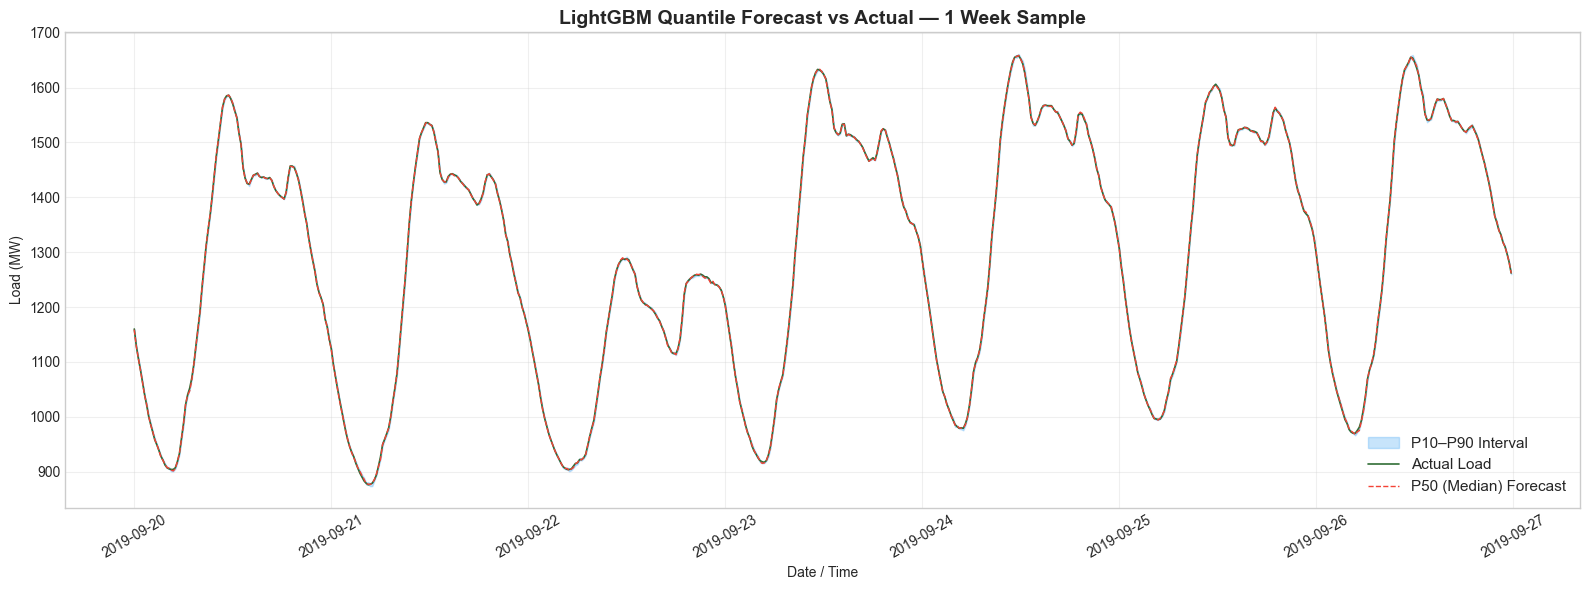

In [19]:
# ---- Plot 1: Quantile Forecast vs Actual (1 week sample) ----
fig, ax = plt.subplots(figsize=(16, 6))

# Take a sample week from the test set
sample_size = 96 * 7  # 1 week of 15-min data
sample = results.iloc[:sample_size]

ax.fill_between(sample['DATETIME'], sample['P10'], sample['P90'],
                alpha=0.25, color='#2196F3', label='P10–P90 Interval')
ax.plot(sample['DATETIME'], sample['Actual'], color='#1B5E20',
        linewidth=1.2, label='Actual Load', alpha=0.9)
ax.plot(sample['DATETIME'], sample['P50'], color='#F44336',
        linewidth=1.0, linestyle='--', label='P50 (Median) Forecast')

ax.set_title('LightGBM Quantile Forecast vs Actual — 1 Week Sample', fontsize=14, fontweight='bold')
ax.set_xlabel('Date / Time')
ax.set_ylabel('Load (MW)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('quantile_forecast_sample.png', dpi=150, bbox_inches='tight')
plt.show()

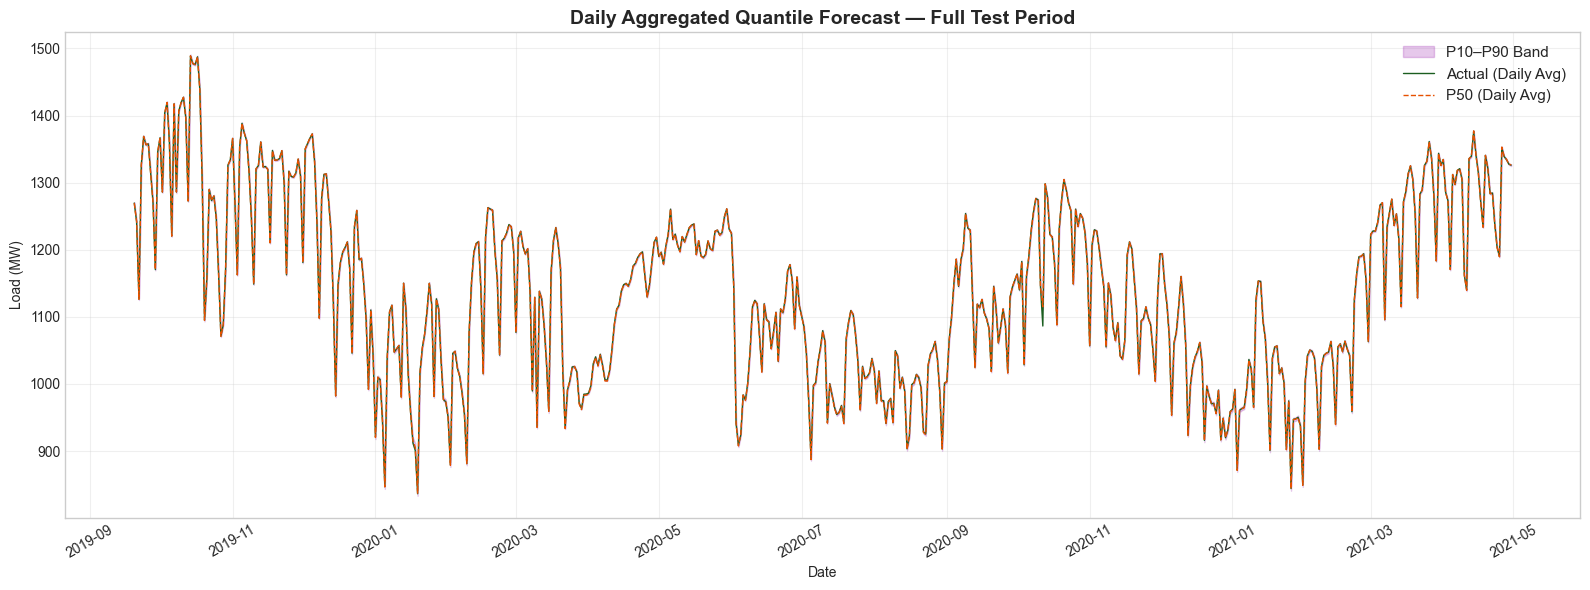

In [20]:
# ---- Plot 2: Full Test Period — Daily Aggregated ----
daily_results = results.set_index('DATETIME').resample('D').mean().reset_index()

fig, ax = plt.subplots(figsize=(16, 6))

ax.fill_between(daily_results['DATETIME'], daily_results['P10'], daily_results['P90'],
                alpha=0.25, color='#9C27B0', label='P10–P90 Band')
ax.plot(daily_results['DATETIME'], daily_results['Actual'], color='#1B5E20',
        linewidth=1.0, label='Actual (Daily Avg)')
ax.plot(daily_results['DATETIME'], daily_results['P50'], color='#E65100',
        linewidth=1.0, linestyle='--', label='P50 (Daily Avg)')

ax.set_title('Daily Aggregated Quantile Forecast — Full Test Period', fontsize=14, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Load (MW)')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('daily_quantile_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

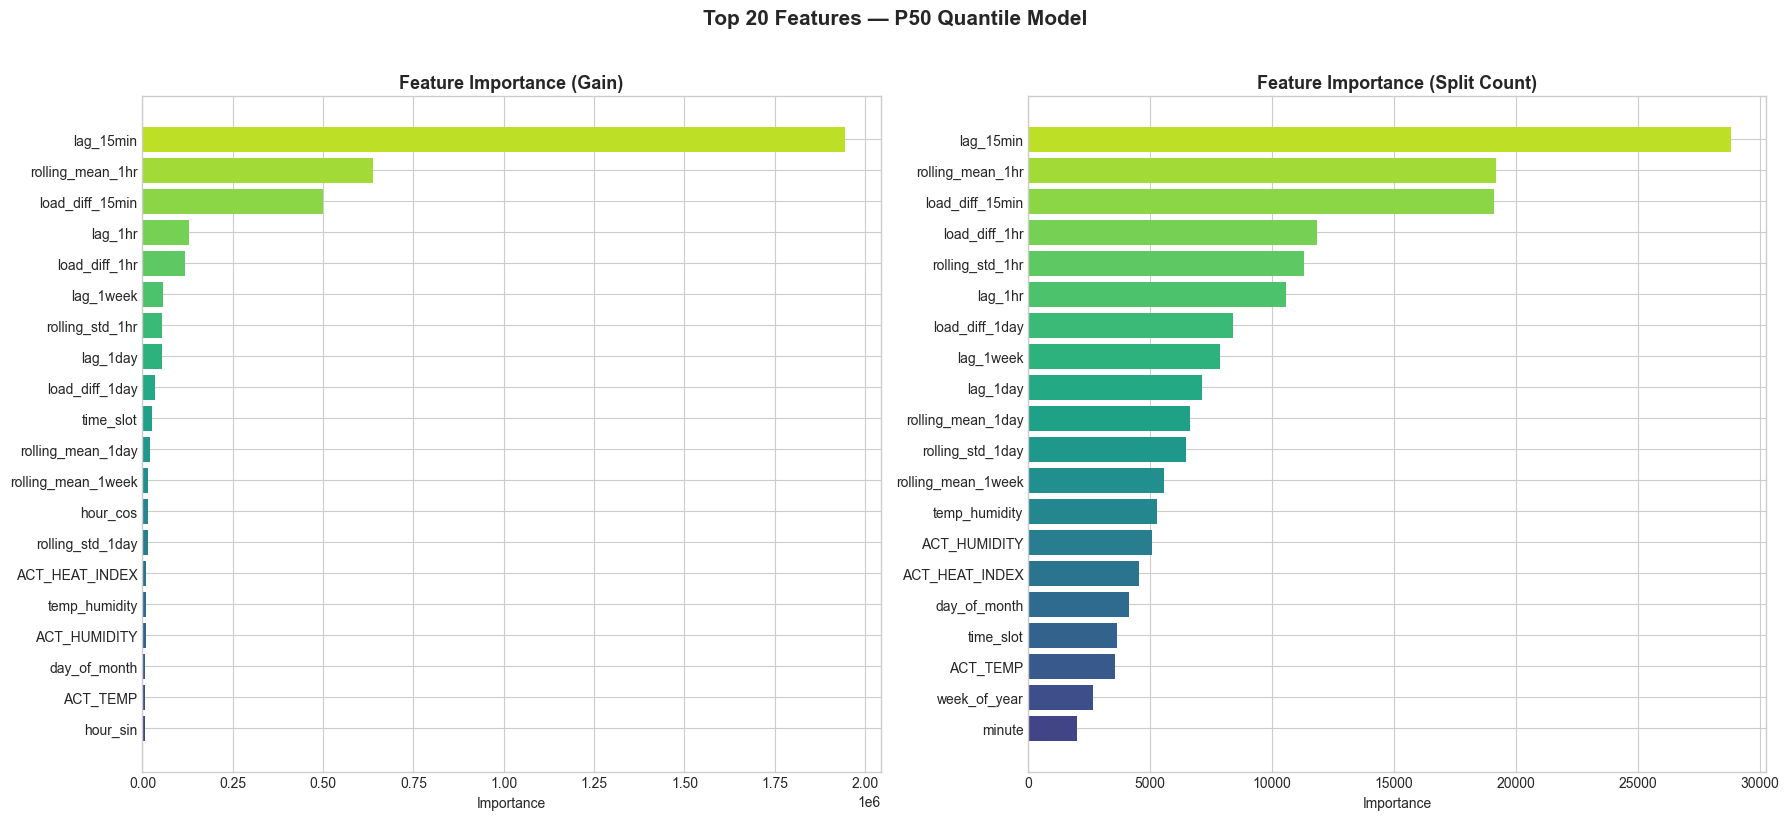

In [21]:
# ---- Plot 3: Feature Importance (P50 model) ----
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for i, (imp_type, title) in enumerate([
    ('gain', 'Feature Importance (Gain)'),
    ('split', 'Feature Importance (Split Count)')
]):
    importance = models['P50'].booster_.feature_importance(importance_type=imp_type)
    feat_imp = pd.DataFrame({
        'Feature': feature_cols,
        'Importance': importance
    }).sort_values('Importance', ascending=True).tail(20)

    axes[i].barh(feat_imp['Feature'], feat_imp['Importance'], color=plt.cm.viridis(np.linspace(0.2, 0.9, 20)))
    axes[i].set_title(title, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Importance')

plt.suptitle('Top 20 Features — P50 Quantile Model', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

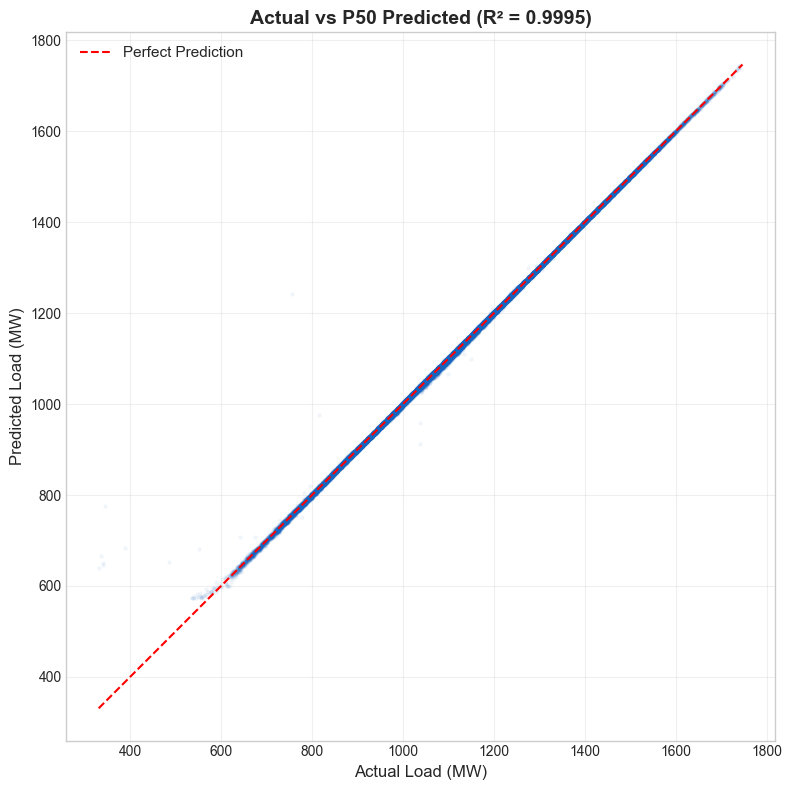

In [22]:
# ---- Plot 4: Actual vs Predicted Scatter ----
fig, ax = plt.subplots(figsize=(8, 8))

ax.scatter(y_test, y_pred_median, alpha=0.04, s=5, color='#1565C0')
min_val = min(y_test.min(), y_pred_median.min())
max_val = max(y_test.max(), y_pred_median.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, label='Perfect Prediction')

ax.set_title(f'Actual vs P50 Predicted (R² = {r2:.4f})', fontsize=14, fontweight='bold')
ax.set_xlabel('Actual Load (MW)', fontsize=12)
ax.set_ylabel('Predicted Load (MW)', fontsize=12)
ax.legend(fontsize=11)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

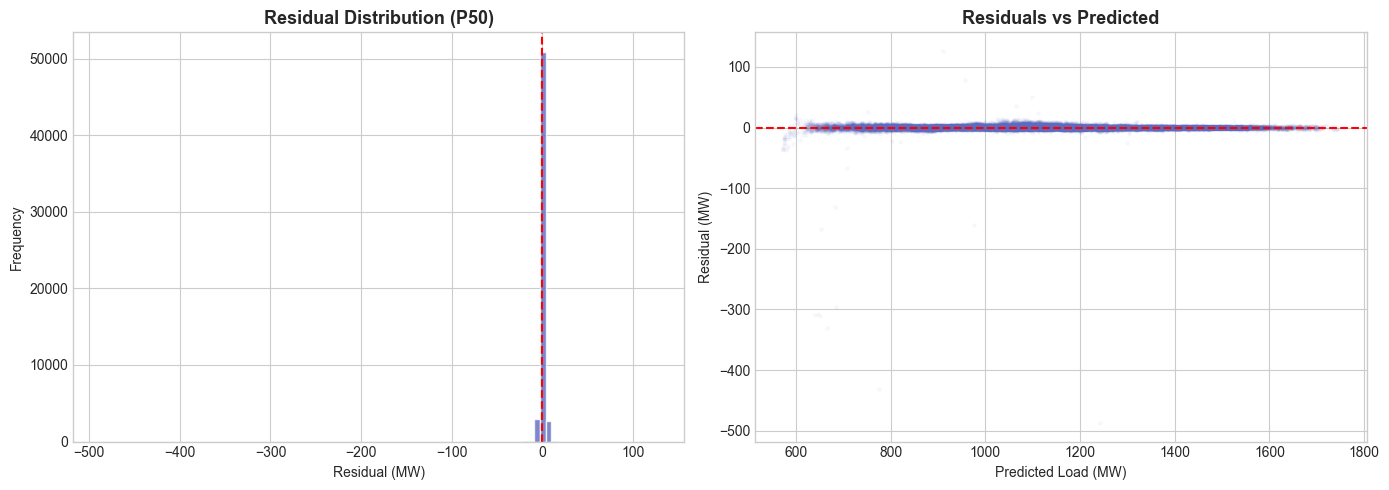

In [23]:
# ---- Plot 5: Residual Distribution ----
residuals = y_test.values - y_pred_median

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(residuals, bins=100, color='#5C6BC0', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0, color='red', linestyle='--', linewidth=1.5)
axes[0].set_title('Residual Distribution (P50)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Residual (MW)')
axes[0].set_ylabel('Frequency')

axes[1].scatter(y_pred_median, residuals, alpha=0.03, s=5, color='#5C6BC0')
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Residuals vs Predicted', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Predicted Load (MW)')
axes[1].set_ylabel('Residual (MW)')

plt.tight_layout()
plt.savefig('residual_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

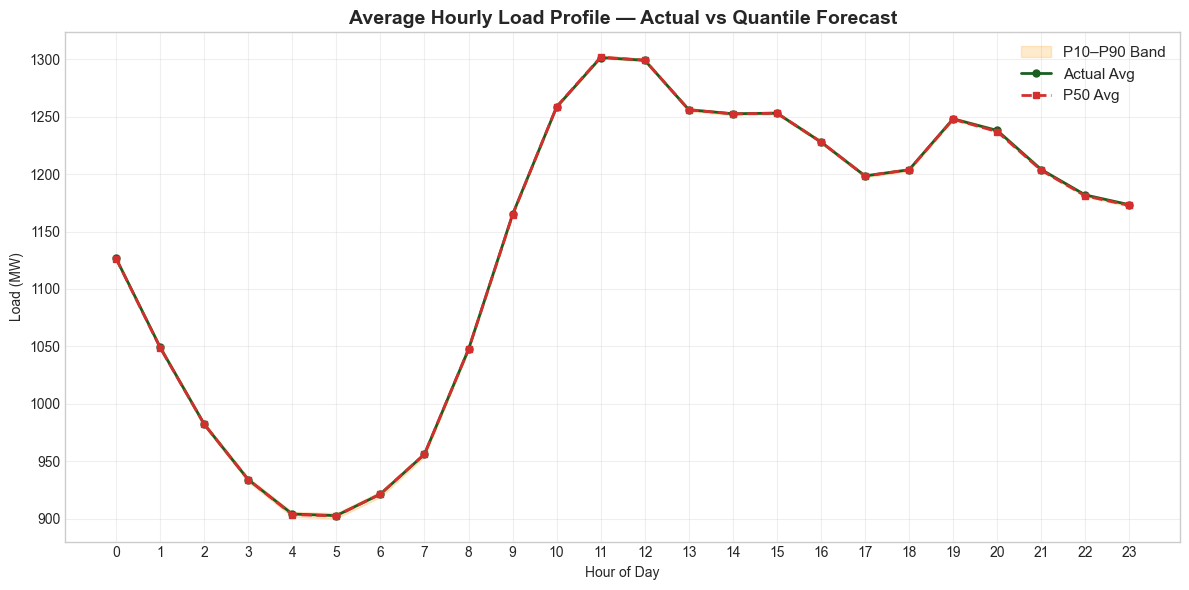

In [24]:
# ---- Plot 6: Hourly Load Profile — Actual vs Quantiles ----
hourly_profile = results.copy()
hourly_profile['hour'] = pd.to_datetime(hourly_profile['DATETIME']).dt.hour
hourly_avg = hourly_profile.groupby('hour')[['Actual', 'P10', 'P50', 'P90']].mean()

fig, ax = plt.subplots(figsize=(12, 6))

ax.fill_between(hourly_avg.index, hourly_avg['P10'], hourly_avg['P90'],
                alpha=0.2, color='#FF9800', label='P10–P90 Band')
ax.plot(hourly_avg.index, hourly_avg['Actual'], 'o-', color='#1B5E20',
        linewidth=2, markersize=5, label='Actual Avg')
ax.plot(hourly_avg.index, hourly_avg['P50'], 's--', color='#D32F2F',
        linewidth=2, markersize=5, label='P50 Avg')

ax.set_title('Average Hourly Load Profile — Actual vs Quantile Forecast', fontsize=14, fontweight='bold')
ax.set_xlabel('Hour of Day')
ax.set_ylabel('Load (MW)')
ax.set_xticks(range(0, 24))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('hourly_load_profile.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Save Models & Results

In [25]:
# Save models
for name, model in models.items():
    model_path = f'lgbm_quantile_{name}.txt'
    model.booster_.save_model(model_path)
    print(f"Saved {name} model → {model_path}")

# Save feature list
with open('feature_columns.txt', 'w') as f:
    f.write('\n'.join(feature_cols))
print("Saved feature columns → feature_columns.txt")

# Save label encoder
with open('label_encoder_event.pkl', 'wb') as f:
    pickle.dump(le_event, f)
print("Saved label encoder → label_encoder_event.pkl")

# Save predictions
results.to_csv('quantile_predictions.csv', index=False)
print("Saved predictions → quantile_predictions.csv")

Saved P10 model → lgbm_quantile_P10.txt
Saved P50 model → lgbm_quantile_P50.txt
Saved P90 model → lgbm_quantile_P90.txt
Saved feature columns → feature_columns.txt
Saved label encoder → label_encoder_event.pkl
Saved predictions → quantile_predictions.csv


In [26]:
# ---- Summary Metrics Table ----
summary = pd.DataFrame({
    'Metric': ['MAE', 'RMSE', 'R²', 'MAPE (%)',
               'Below P10 (%)', 'Above P90 (%)', 'Within P10-P90 (%)',
               'Avg Interval Width (MW)',
               'Train Samples', 'Test Samples', 'Features'],
    'Value': [
        f"{mae:.2f}",
        f"{rmse:.2f}",
        f"{r2:.4f}",
        f"{mape:.2f}",
        f"{below_p10:.2f}",
        f"{above_p90:.2f}",
        f"{within_interval:.2f}",
        f"{results['Interval_Width'].mean():.2f}",
        f"{len(X_train):,}",
        f"{len(X_test):,}",
        f"{len(feature_cols)}"
    ]
})

print("\n" + "=" * 50)
print("  MODEL TRAINING SUMMARY")
print("=" * 50)
print(summary.to_string(index=False))
print("=" * 50)


  MODEL TRAINING SUMMARY
                 Metric   Value
                    MAE    1.49
                   RMSE    4.69
                     R²  0.9995
               MAPE (%)    0.15
          Below P10 (%)   14.39
          Above P90 (%)   18.28
     Within P10-P90 (%)   67.70
Avg Interval Width (MW)    3.09
          Train Samples 226,175
           Test Samples  56,544
               Features      38


---
## 9. Inference Example — Load the Saved Models

In [27]:
# Example: Load saved models and make predictions
loaded_models = {}
for name in ['P10', 'P50', 'P90']:
    booster = lgb.Booster(model_file=f'lgbm_quantile_{name}.txt')
    loaded_models[name] = booster

# Predict on a test sample
sample_X = X_test.iloc[:10]
print("Inference with loaded models:")
print(f"{'Index':<6} {'Actual':<10} {'P10':<10} {'P50':<10} {'P90':<10}")
print("-" * 46)
for i in range(10):
    p10 = loaded_models['P10'].predict(sample_X.iloc[[i]])[0]
    p50 = loaded_models['P50'].predict(sample_X.iloc[[i]])[0]
    p90 = loaded_models['P90'].predict(sample_X.iloc[[i]])[0]
    actual = y_test.iloc[i]
    print(f"{i:<6} {actual:<10.1f} {p10:<10.1f} {p50:<10.1f} {p90:<10.1f}")

print("\n✅ Models loaded and inference successful!")

Inference with loaded models:
Index  Actual     P10        P50        P90       
----------------------------------------------
0      1160.0     1153.3     1158.7     1159.8    
1      1129.0     1126.4     1128.2     1129.3    
2      1106.0     1104.9     1106.5     1107.7    
3      1086.0     1084.3     1085.6     1086.8    
4      1064.0     1062.2     1063.4     1064.3    
5      1041.0     1038.8     1038.9     1039.6    
6      1022.0     1023.4     1023.3     1024.3    
7      1001.0     1000.1     1001.6     1003.0    
8      986.0      984.6      985.3      989.0     
9      972.0      971.7      973.4      974.0     

✅ Models loaded and inference successful!


---

### 📋 Notes

| Item | Detail |
|------|--------|
| **Algorithm** | LightGBM with `objective='quantile'` |
| **Quantiles** | P10, P50, P90 |
| **Train/Test** | 80/20 time-based split |
| **Features** | Weather, time, lag, rolling, cyclical, interactions |
| **Saved Artifacts** | 3 model files, predictions CSV, feature list, label encoder |

---